In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy import stats
import smarts_cerebellum.globals as gl

# using observed values, since each subject should have their own dot
df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')
df = df[(df.metric == 'FaMap') & (df.isPatient == 1)]

/localscratch/tmp/ipykernel_8745/3118935468.py:10: DtypeWarning: Columns (2,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


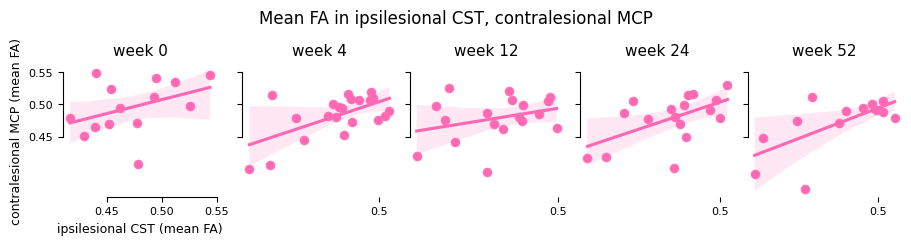

In [128]:
fig, axs = plt.subplots(1, 5, figsize = (9, 2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    df_week = df[df.week_num == week]
    df_week = df_week.pivot_table(index = 'subj_id',columns = 'Object', values = 'Mean')
    # ipsilesional CST = CST_R; contralesional MCP = MCP_L
    ax = axs[i]
    sns.scatterplot(x = df_week['CST_R'], y =  df_week['MCP_L'], ax = ax, color = 'hotpink')
    sns.regplot(x = df_week['CST_R'], y =  df_week['MCP_L'], ax = ax, color = 'hotpink')
    sns.despine(trim = True)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'week {week}')

axs[0].set_xlabel("ipsilesional CST (mean FA)")
axs[0].set_ylabel("contralesional MCP (mean FA)")

fig.suptitle(f"Mean FA in ipsilesional CST, contralesional MCP", y = 1.15)
plt.show()



In [129]:
from scipy import stats
print("---pearson R correlation--- \n")
for week in gl.weeks:
    corr, p_val = stats.pearsonr(df[(df.week_num == week) & (df.Object == 'CST_R')]['Mean'], df[(df.week_num == week) & (df.Object == 'MCP_L')]['Mean'])
    print(f'*week {week}*: correlation = {corr}, p-value = {p_val} \n')

---pearson R correlation--- 

*week 0*: correlation = 0.3943946167627921, p-value = 0.162880404989412 

*week 4*: correlation = 0.607177444740452, p-value = 0.0035119582563740933 

*week 12*: correlation = 0.30874469157572093, p-value = 0.21254938750338426 

*week 24*: correlation = 0.5618220605811546, p-value = 0.018921631732940734 

*week 52*: correlation = 0.6452143829335713, p-value = 0.017245285065201715 

